# Descriptive Analysis: HANNA

This notebook analyzes the original HANNA dataset  

**Source:** https://github.com/dig-team/hanna-benchmark-asg  
**Content:** 1,056 stories, 6 human criteria (Likert 1–5), 11 generators, 96 prompts  

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, spearmanr
import warnings

In [2]:
# Plotting aesthetics
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Color palette
HT_COLOR = '#cb1f73'
MT_COLOR = '#9E9E9E'

GENERATORS = ['Human', 'BertGeneration', 'CTRL', 'Fusion', 'GPT', 'GPT-2', 'GPT-2 (tag)', 'HINT', 'RoBERTa', 'TD-VAE', 'XLNet']
GENERATOR_COLORS = {g: MT_COLOR for g in GENERATORS}
GENERATOR_COLORS['Human'] = HT_COLOR

HUMAN_CRITERIA = ['Relevance', 'Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity']

## Load data

In [3]:
HANNA_PATH = '../data/hanna_stories_annotations.csv'

hanna = pd.read_csv(HANNA_PATH)
print(f'Shape: {hanna.shape}')
print(f'Columns: {list(hanna.columns)}')
hanna.head(3)

Shape: (3168, 15)
Columns: ['Story ID', 'Prompt', 'Human', 'Story', 'Model', 'Relevance', 'Coherence', 'Empathy', 'Surprise', 'Engagement', 'Complexity', 'Worker ID', 'Assignment ID', 'Work time in seconds', 'Name']


,Story ID,Prompt,Human,Story,Model,Relevance,Coherence,Empathy,Surprise,Engagement,Complexity,Worker ID,Assignment ID,Work time in seconds,Name
0,0,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...","3,000 years have I been fighting. Every mornin...",Human,4,4,3,2,4,4,A2VE5IV9OD2SK1,3X87C8JFVHIT235KQ4UTS8264I6SQJ,579.0,NaN
1,0,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...","3,000 years have I been fighting. Every mornin...",Human,5,5,1,3,4,1,A1IZ4NX41GKU4X,3DR23U6WEGL5K0SU6D4J8W9EM9LTE7,82.0,none
2,0,When you die the afterlife is an arena where y...,"3,000 years have I been fighting. Every mornin...","3,000 years have I been fighting. Every mornin...",Human,2,2,3,2,2,3,A264NN7JBX4UDQ,3UJ1CZ6IZSW49HMM6C6QUX7F7UV5SA,273.0,none


In [4]:
# Missing values
print('Missing values per column:')
print(hanna.isnull().sum())

# Generators
print(f'\nGenerators ({hanna["Model"].nunique()}): {sorted(hanna["Model"].unique())}')
print(f'Prompts: {hanna["Prompt"].nunique()}')
print(f'Unique Story-IDs: {hanna["Story ID"].nunique()}')

Missing values per column:
Story ID                  0
Prompt                    0
Human                     0
Story                     0
Model                     0
Relevance                 0
Coherence                 0
Empathy                   0
Surprise                  0
Engagement                0
Complexity                0
Worker ID                 0
Assignment ID             0
Work time in seconds      0
Name                    840
dtype: int64

Generators (11): ['BertGeneration', 'CTRL', 'Fusion', 'GPT', 'GPT-2', 'GPT-2 (tag)', 'HINT', 'Human', 'RoBERTa', 'TD-VAE', 'XLNet']
Prompts: 96
Unique Story-IDs: 1056


In [5]:
# Aggregate to story level (mean over raters)
stories = (hanna.groupby(['Story ID', 'Model', 'Prompt'])[HUMAN_CRITERIA].mean().reset_index())
stories['Overall'] = stories[HUMAN_CRITERIA].mean(axis=1)

print(f'Stories (aggregated): {len(stories)}')
stories.head(3)

Stories (aggregated): 1056


,Story ID,Model,Prompt,Relevance,Coherence,Empathy,Surprise,Engagement,Complexity,Overall
0,0,Human,When you die the afterlife is an arena where y...,3.666667,3.666667,2.333333,2.333333,3.333333,2.666667,3.000000
1,1,Human,A new law is enacted that erases soldiers memo...,5.000000,4.666667,4.000000,3.666667,3.666667,4.000000,4.166667
2,2,Human,A scientific study proves that all humans have...,4.666667,4.666667,4.000000,4.333333,4.000000,4.333333,4.333333


## Descriptive Statistics (Story Level)

### Summary of all criteria

In [6]:
desc = stories[HUMAN_CRITERIA + ['Overall']].describe().T
desc['skewness'] = stories[HUMAN_CRITERIA + ['Overall']].skew()
desc['kurtosis'] = stories[HUMAN_CRITERIA + ['Overall']].kurtosis()
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Relevance,1056.0,2.625,0.955,1.0,2.000,2.667,3.333,5.000,0.376,-0.258
Coherence,1056.0,3.150,0.752,1.0,2.667,3.000,3.667,5.000,0.182,0.193
Empathy,1056.0,2.295,0.719,1.0,1.667,2.333,2.667,4.667,0.397,0.139
Surprise,1056.0,2.107,0.704,1.0,1.667,2.000,2.333,4.667,0.843,0.708
Engagement,1056.0,2.676,0.795,1.0,2.000,2.667,3.333,5.000,0.282,-0.076
Complexity,1056.0,2.452,0.788,1.0,2.000,2.333,3.000,5.000,0.423,0.170
Overall,1056.0,2.551,0.649,1.0,2.111,2.500,2.889,4.667,0.609,0.561


### Score distribution per criterion

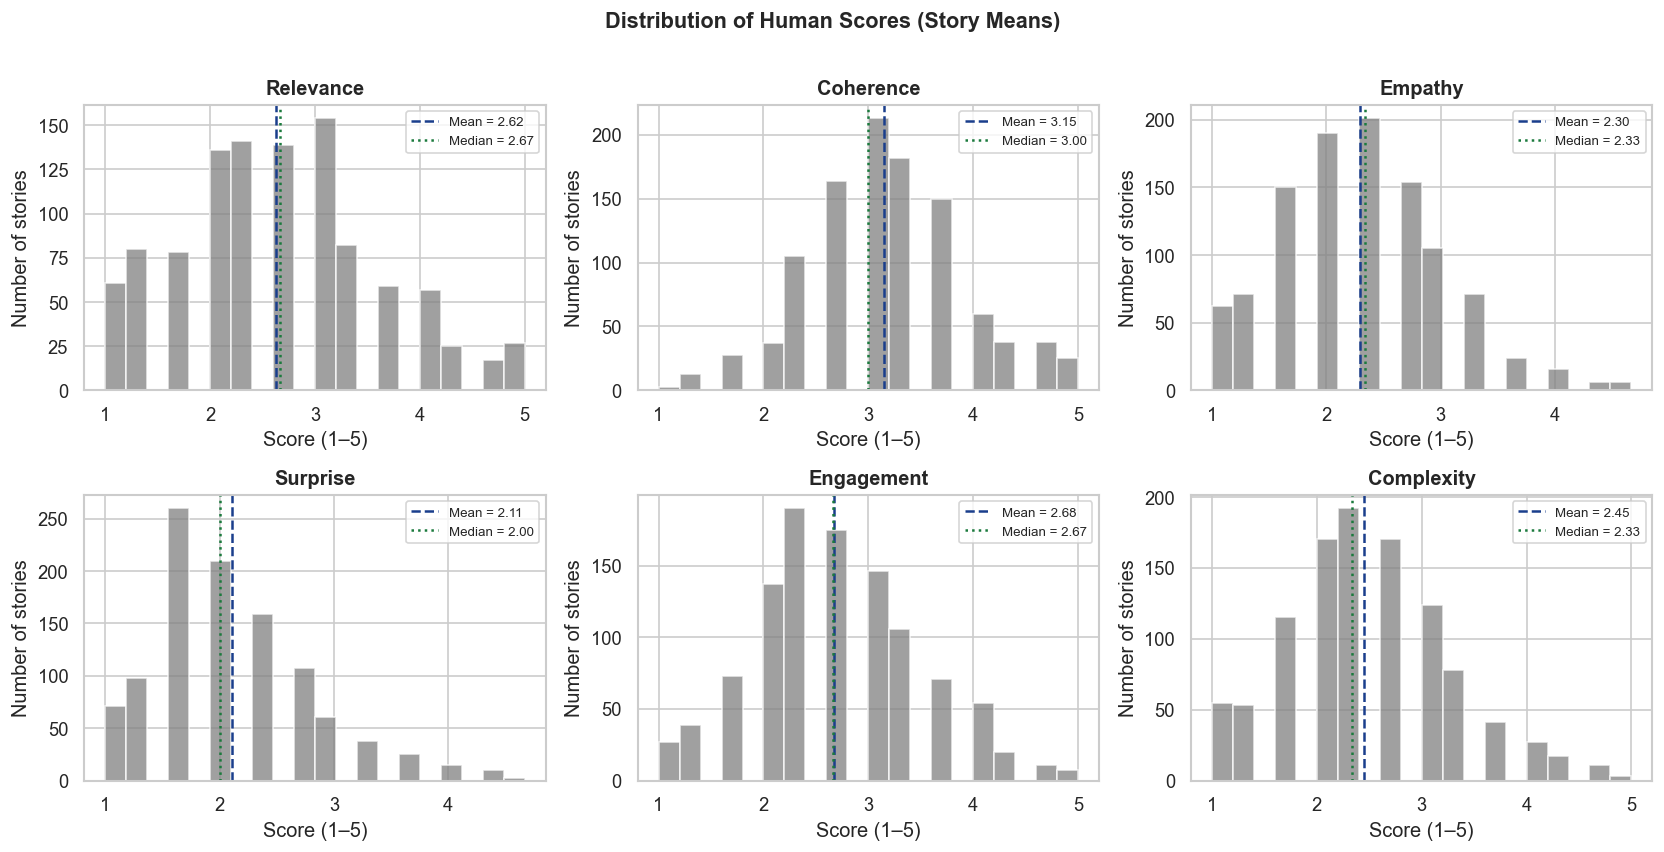

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
axes = axes.flatten()

for i, crit in enumerate(HUMAN_CRITERIA):
    ax = axes[i]
    ax.hist(stories[crit].dropna(), bins=20, color='#808080', alpha=0.75, edgecolor='white')
    ax.axvline(stories[crit].mean(), color='#1a3e8c', linestyle='--', linewidth=1.5,
               label=f'Mean = {stories[crit].mean():.2f}')
    ax.axvline(stories[crit].median(), color='#1b7a3d', linestyle=':', linewidth=1.5,
               label=f'Median = {stories[crit].median():.2f}')
    ax.set_title(crit, fontweight='bold')
    ax.set_xlabel('Score (1–5)')
    ax.set_ylabel('Number of stories')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Human Scores (Story Means)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/data_description/hanna_plot_score_distributions.png', bbox_inches='tight')
plt.show()

### Scores by generator

/var/folders/mf/zdrsq7ms1cs8nyqwtp9c01th0000gp/T/ipykernel_73237/1294379911.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/mf/zdrsq7ms1cs8nyqwtp9c01th0000gp/T/ipykernel_73237/1294379911.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/mf/zdrsq7ms1cs8nyqwtp9c01th0000gp/T/ipykernel_73237/1294379911.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/mf/zdrsq7ms1cs8nyqwtp9c01th0000gp/T/ipykernel_73237/1294379911.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

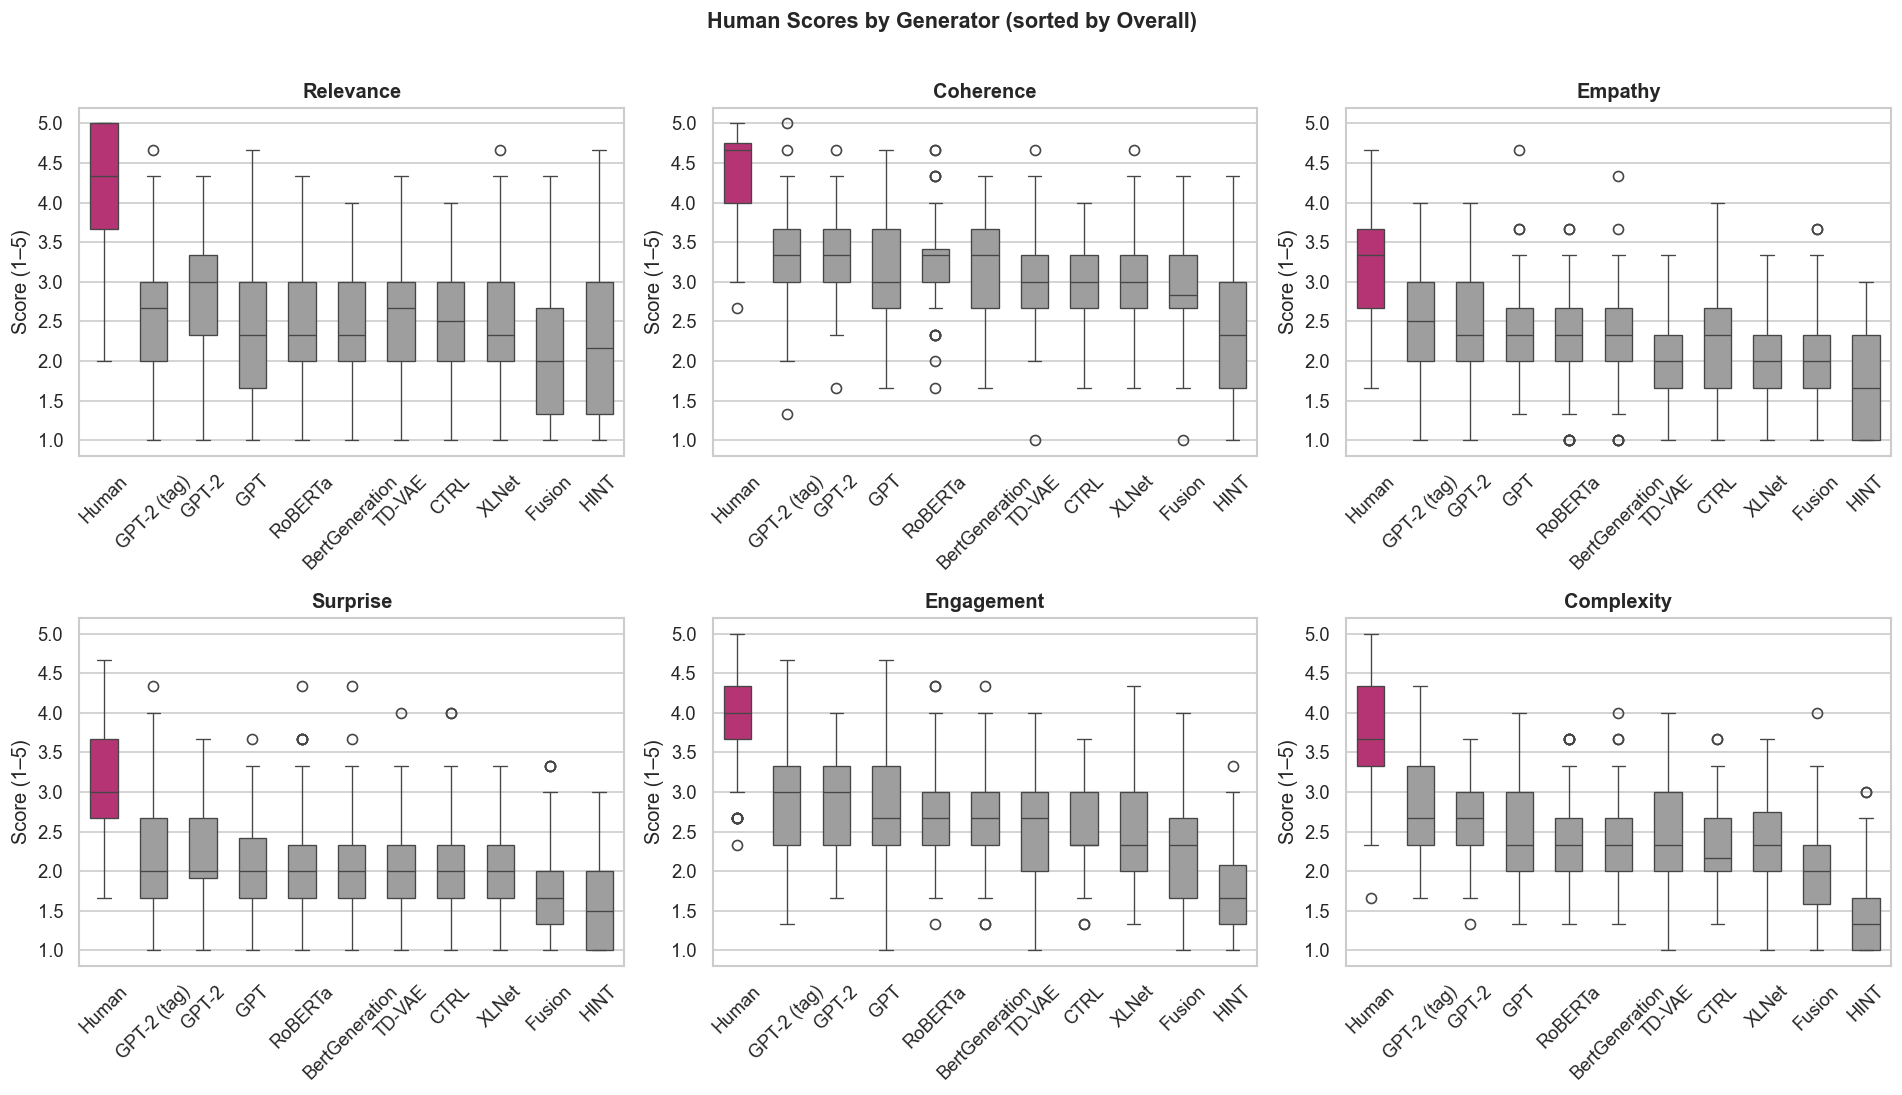

In [8]:
# Order by overall score
gen_order = (
    stories.groupby('Model')['Overall']
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, crit in enumerate(HUMAN_CRITERIA):
    ax = axes[i]
    palette = [GENERATOR_COLORS.get(g, MT_COLOR) for g in gen_order]
    
    sns.boxplot(
        data=stories, x='Model', y=crit,
        order=gen_order, palette=palette,
        width=0.55, linewidth=0.8, ax=ax
    )
    ax.set_title(crit, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score (1–5)')
    ax.set_ylim(0.8, 5.2)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Human Scores by Generator (sorted by Overall)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/data_description/hanna_plot_scores_by_generator.png', bbox_inches='tight')
plt.show()

### Heatmap: Mean scores per generator × criterion

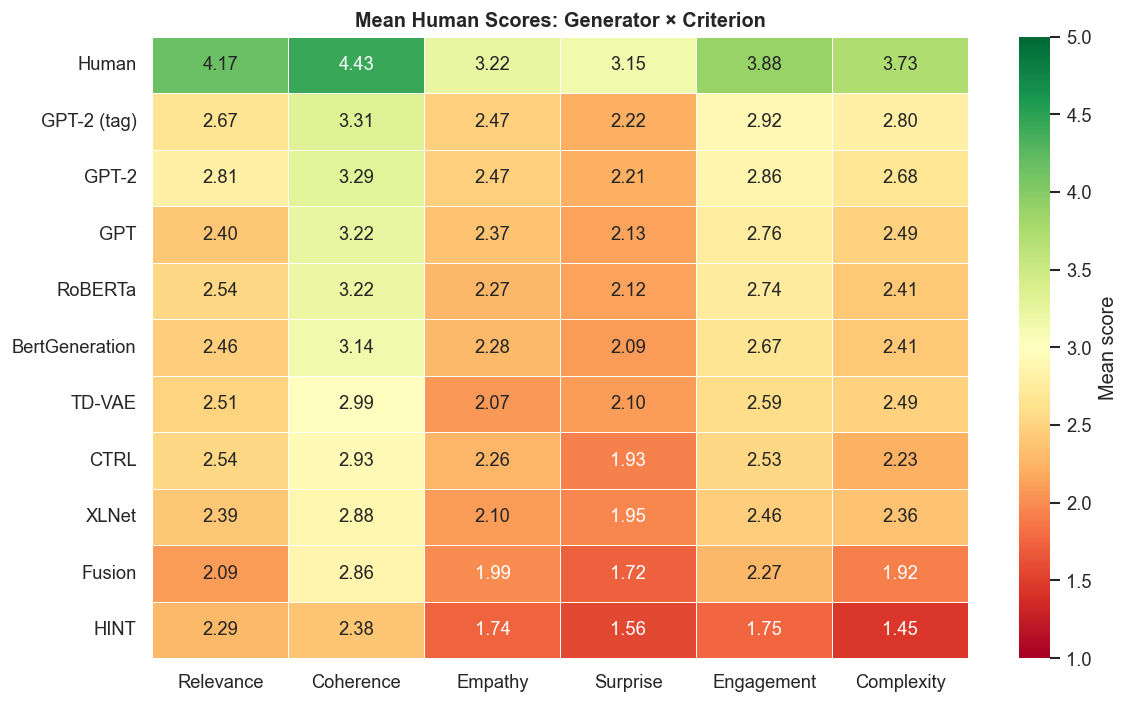

In [9]:
heatmap_data = (stories.groupby('Model')[HUMAN_CRITERIA].mean().loc[gen_order])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=1, vmax=5,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Mean score'}
)
ax.set_title('Mean Human Scores: Generator × Criterion', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../figures/data_description/hanna_plot_heatmap_gen_criteria.png', bbox_inches='tight')
plt.show()

### Correlation between criteria (Spearman)

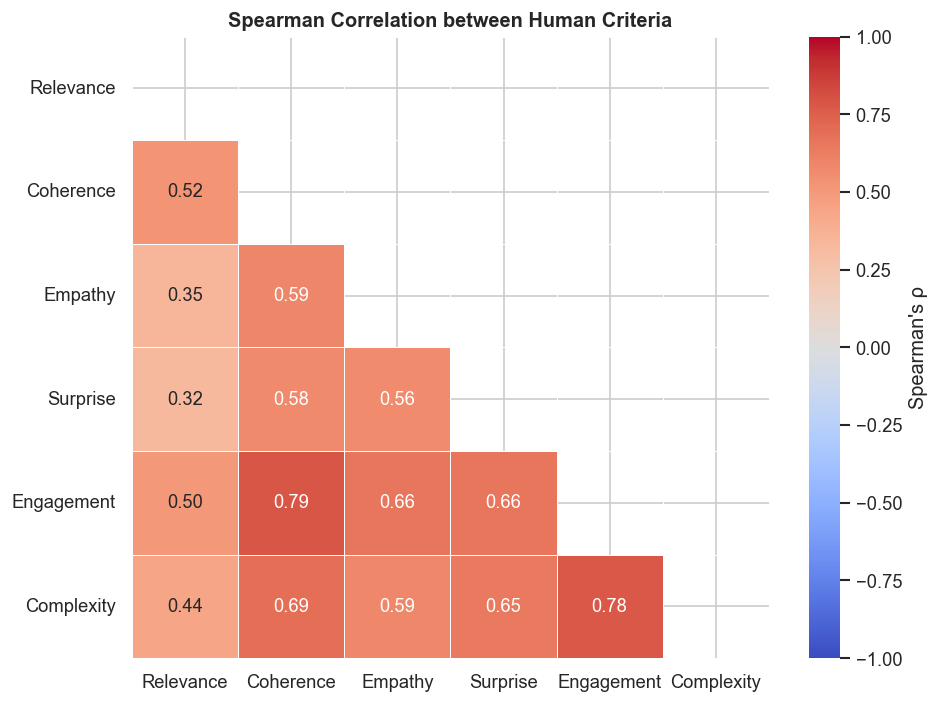

In [10]:
corr_matrix = stories[HUMAN_CRITERIA].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'label': "Spearman's ρ"}
)
ax.set_title('Spearman Correlation between Human Criteria', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/data_description/hanna_plot_criteria_correlation.png', bbox_inches='tight')
plt.show()

### Inter-Annotator Agreement (Rater Level)

-> Spread of rater scores per story as a measure of agreement

Mean rater spread (SD) per criterion:
Relevance     1.203
Coherence     1.307
Empathy       0.922
Surprise      1.015
Engagement    0.944
Complexity    0.793

Overall average: 1.031


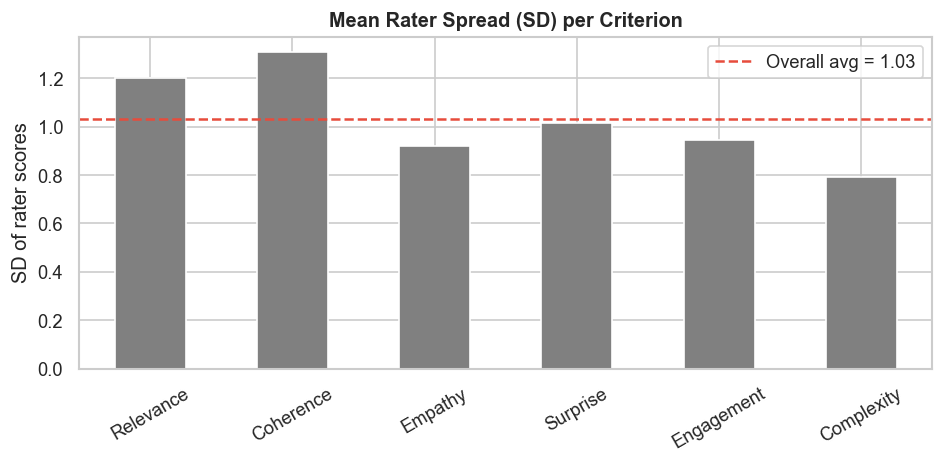

In [11]:
# Standard deviation of rater scores per story and criterion
rater_std = hanna.groupby('Story ID')[HUMAN_CRITERIA].std().reset_index()
rater_std_mean = rater_std[HUMAN_CRITERIA].mean()

print('Mean rater spread (SD) per criterion:')
print(rater_std_mean.round(3).to_string())
print(f'\nOverall average: {rater_std_mean.mean():.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
rater_std_mean.plot(kind='bar', color='#808080', ax=ax, edgecolor='white')
ax.axhline(rater_std_mean.mean(), color='#e74c3c', linestyle='--', label=f'Overall avg = {rater_std_mean.mean():.2f}')
ax.set_title('Mean Rater Spread (SD) per Criterion', fontweight='bold')
ax.set_ylabel('SD of rater scores')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('../figures/data_description/hanna_plot_rater_agreement.png', bbox_inches='tight')
plt.show()

## Prompt Level: Variability of Quality Judgments

In [12]:
# How much does the Overall score vary between generators per prompt?
prompt_var = (
    stories.groupby('Prompt')['Overall']
    .agg(['mean', 'std', 'min', 'max'])
    .rename(columns={'mean': 'Ø Score', 'std': 'SD', 'min': 'Min', 'max': 'Max'})
    .assign(range=lambda x: x['Max'] - x['Min'])
)

print('Prompts with highest variance (Top 10):')
print(prompt_var.sort_values('SD', ascending=False).head(10).round(3).to_string())

Prompts with highest variance (Top 10):
                                                                                                                                                                                                                                                                                                      Ø Score     SD    Min    Max  range
Prompt                                                                                                                                                                                                                                                                                                                                   
A scientific study proves that all humans have been breathing a mind-altering gas from birth. It has been in the air since the beginning of recorded time. People have been in a constant state of being high. Until now. Specialised gas masks are handed out and people have begun to act strange.    2.63

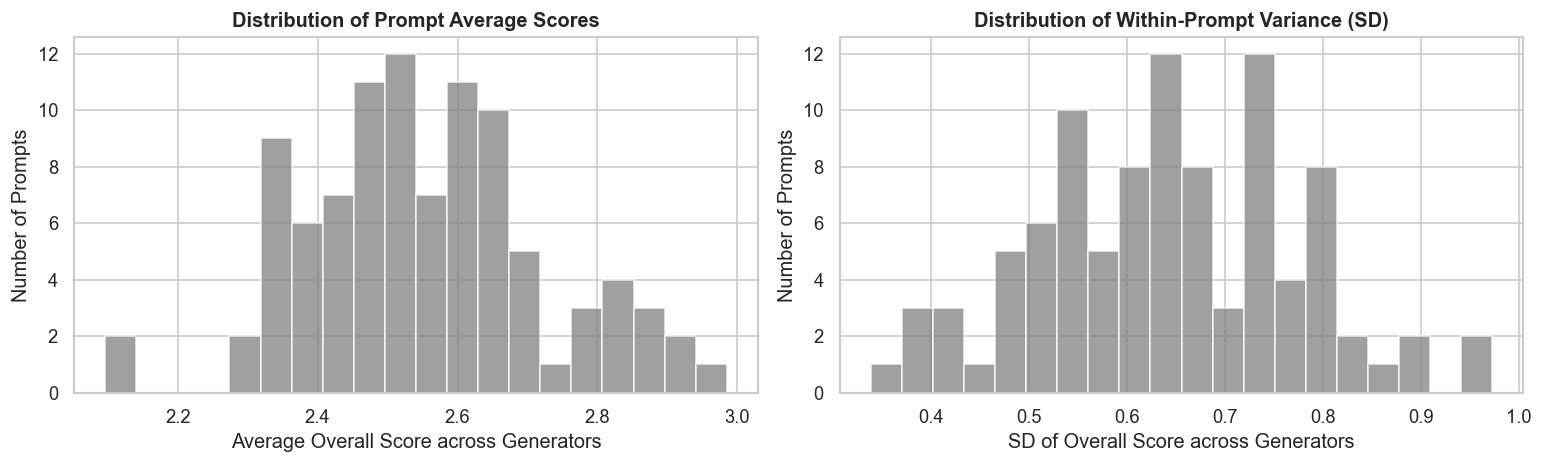

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(prompt_var['Ø Score'], bins=20, color='#808080', alpha=0.75, edgecolor='white')
axes[0].set_title('Distribution of Prompt Average Scores', fontweight='bold')
axes[0].set_xlabel('Average Overall Score across Generators')
axes[0].set_ylabel('Number of Prompts')

axes[1].hist(prompt_var['SD'], bins=20, color='#808080', alpha=0.75, edgecolor='white')
axes[1].set_title('Distribution of Within-Prompt Variance (SD)', fontweight='bold')
axes[1].set_xlabel('SD of Overall Score across Generators')
axes[1].set_ylabel('Number of Prompts')

plt.tight_layout()
plt.savefig('../figures/data_description/hanna_plot_prompt_variability.png', bbox_inches='tight')
plt.show()

## Quality-analysis sample descriptives


In [16]:
# Load the primary 68-prompt quality-analysis sample by Story ID
# (exported directly from hanna_quality_analysis.ipynb -- no prompt-text matching needed).
from pathlib import Path

QUALITY_SAMPLE_IDS_PATH = Path('../quality/results/hanna_quality_sample_story_ids.csv')
if not QUALITY_SAMPLE_IDS_PATH.exists():
    raise FileNotFoundError(
        'Run hanna_quality_analysis.ipynb first so that '
        f'{QUALITY_SAMPLE_IDS_PATH} is available.'
    )

quality_sample_ids = pd.read_csv(QUALITY_SAMPLE_IDS_PATH)['Story ID']
quality_stories = stories.loc[stories['Story ID'].isin(quality_sample_ids)].copy()

print(f'Primary HANNA quality sample: {quality_stories["Prompt"].nunique()} prompts, '
      f'{len(quality_stories)} model stories, {quality_stories["Model"].nunique()} generators')

assert quality_stories['Prompt'].nunique() == 68, 'Expected 68 primary-analysis prompts.'
assert len(quality_stories) == 680, 'Expected 680 model stories in the primary HANNA sample.'

Primary HANNA quality sample: 68 prompts, 680 model stories, 10 generators


In [17]:
# Appendix-ready descriptive statistics for the primary HANNA quality sample
quality_columns = HUMAN_CRITERIA + ['Overall']

hanna_quality_descriptives = pd.DataFrame({
    'N': quality_stories[quality_columns].count(),
    'Mean': quality_stories[quality_columns].mean(),
    'SD': quality_stories[quality_columns].std(),
    'Median': quality_stories[quality_columns].median(),
    'Q1': quality_stories[quality_columns].quantile(0.25),
    'Q3': quality_stories[quality_columns].quantile(0.75),
    'Min': quality_stories[quality_columns].min(),
    'Max': quality_stories[quality_columns].max(),
})

HANNA_DESC_OUT = Path('../figures/data_description/hanna_quality_analysis_sample_descriptives.csv')
HANNA_DESC_OUT.parent.mkdir(parents=True, exist_ok=True)
hanna_quality_descriptives.to_csv(HANNA_DESC_OUT)

display(
    hanna_quality_descriptives.round(2)
    .style.set_caption('HANNA primary quality-analysis sample: descriptive statistics')
)


,N,Mean,SD,Median,Q1,Q3,Min,Max
Relevance,680,2.490000,0.830000,2.330000,2.000000,3.000000,1.000000,4.670000
Coherence,680,3.050000,0.640000,3.000000,2.670000,3.330000,1.330000,4.670000
Empathy,680,2.230000,0.630000,2.330000,1.670000,2.670000,1.000000,4.330000
Surprise,680,2.040000,0.610000,2.000000,1.670000,2.330000,1.000000,4.330000
Engagement,680,2.600000,0.710000,2.670000,2.000000,3.000000,1.000000,4.670000
Complexity,680,2.360000,0.670000,2.330000,2.000000,2.670000,1.000000,4.330000
Overall,680,2.460000,0.530000,2.440000,2.110000,2.830000,1.060000,4.110000


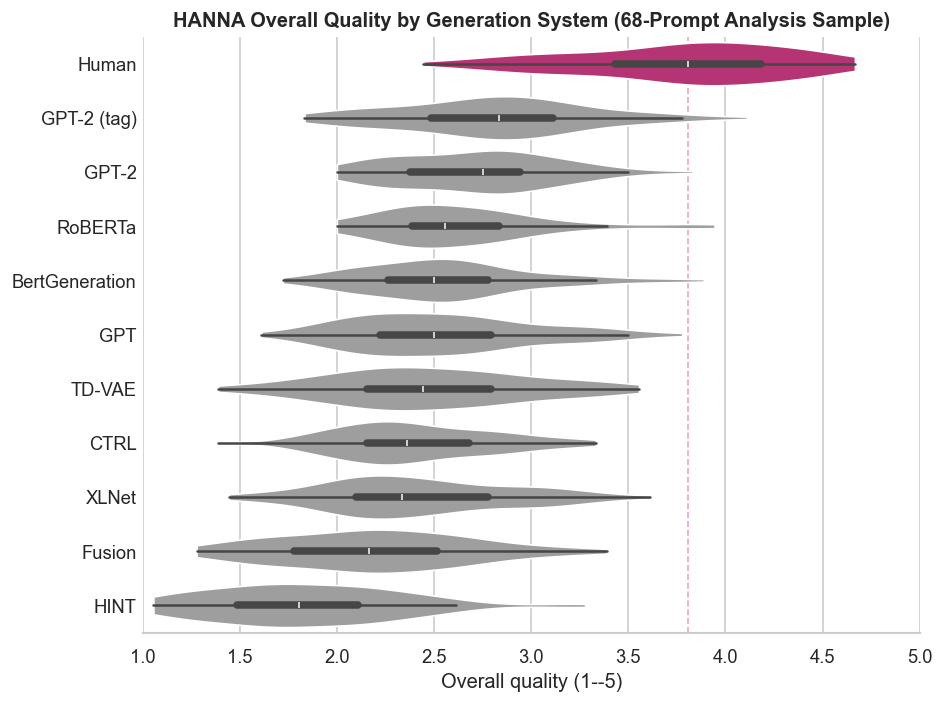

In [18]:
# Overall quality distribution by generation system in the primary HANNA sample,
# with the Human continuations of the same 68 prompts shown as a reference category.
human_quality_stories = stories.loc[
    (stories['Model'] == 'Human')
    & stories['Prompt'].isin(quality_stories['Prompt'].unique())
].copy()

plot_stories = pd.concat([quality_stories, human_quality_stories], ignore_index=True)

# Sort by median quality (descending) rather than a fixed/alphabetical order --
# Human ends up on top on its own merits, and the ranking reads directly off the axis.
quality_generator_order = (
    plot_stories.groupby('Model')['Overall']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
quality_palette = [GENERATOR_COLORS.get(g, MT_COLOR) for g in quality_generator_order]

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(
    data=plot_stories,
    x='Overall',
    y='Model',
    order=quality_generator_order,
    hue='Model',
    hue_order=quality_generator_order,
    palette=quality_palette,
    legend=False,
    inner='box',
    cut=0,
    linewidth=1,
    density_norm='width',
    ax=ax,
)
for coll in ax.collections:
    coll.set_edgecolor('white')

ax.axvline(
    human_quality_stories['Overall'].median(),
    color=HT_COLOR, linestyle='--', linewidth=1, alpha=0.4, zorder=0,
)

ax.set_title(
    'HANNA Overall Quality by Generation System (68-Prompt Analysis Sample)',
    fontweight='bold',
)
ax.set_xlabel('Overall quality (1--5)')
ax.set_ylabel('')
ax.set_xlim(1, 5)
sns.despine(left=True)
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.savefig(
    '../figures/data_description/hanna_quality_overall_by_generator_primary_sample.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()